# `closed_les` parameter toy

Hands-on feel for the two Stage-0 design variables of the closed pipeline:

| param | shape | meaning |
|---|---|---|
| `z` | `(rows, cols)` | latent for the per-cut **void aspect ratio** `r = sigmoid(z)` |
| `bnd_logits` | `(n_logits,)` | per-edge logits -> **boundary slider** positions (cumulative softmax) |

Everything here is the *flat closed sheet* — Stage 0 only. Deployment (Stage 2 physics)
is out of scope; what the flat sheet controls is the **cut length**, which is what opens
into a void when the sheet is pulled.

In the drawings: orange = panels (shrunk slightly so the cuts are visible),
red = the slits that become voids, dots = cut endpoints (the future hinges).

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from nff.topology.closed_builder_jax import (
    build_deploy_structure, build_boundary_edges,
    boundary_flat_from_logits, solve_cut_vertices_jax)

%matplotlib inline

try:
    from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
    HAVE_WIDGETS = True
except ImportError:                       # static fallback
    HAVE_WIDGETS = False
    def interact(f, **kw):
        f(**{k: (v.value if hasattr(v, 'value') else v) for k, v in kw.items()})


def build(M=3, N=3, r=0.25, logits=None, spacing=1.0):
    """Flat closed sheet from (aspect ratios, boundary logits). Mirrors apply_closed_les_mapping."""
    struct = build_deploy_structure(M, N)
    sliders = build_boundary_edges(struct, spacing=spacing, spacing_y=spacing)
    lg = jnp.zeros(sliders['n_logits']) if logits is None else jnp.asarray(logits, dtype=float)
    boundary = boundary_flat_from_logits(sliders, lg)
    r_arr = jnp.broadcast_to(jnp.asarray(r, dtype=float), (struct['rows'], struct['cols']))
    coords = np.asarray(solve_cut_vertices_jax(struct, boundary, r_arr))
    return struct, sliders, coords, coords[np.asarray(struct['corner_pid'])]


def draw(ax, coords, panels, shrink=0.06, title=None):
    for p in panels:
        c = p.mean(0)
        ax.add_patch(Polygon(c + (p - c) * (1 - shrink), closed=True,
                             fc="#F58025", ec="#7a3d10", lw=0.7, zorder=2))
    for a, b in coords.reshape(-1, 2, 2):            # each cut owns points 2k, 2k+1
        if np.linalg.norm(a - b) > 1e-9:
            ax.plot(*zip(a, b), c="#D62828", lw=2.2, zorder=3, solid_capstyle="round")
    ax.scatter(coords[:, 0], coords[:, 1], s=9, c="#1d3557", zorder=4)
    ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=9)


def metrics(coords, panels):
    x, y = panels[..., 0], panels[..., 1]
    area = 0.5 * np.sum(x * np.roll(y, -1, -1) - np.roll(x, -1, -1) * y, -1)
    cut = np.linalg.norm(coords[0::2] - coords[1::2], axis=-1)
    return dict(min_area=area.min(), max_area=area.max(),
                cut_mean=cut.mean(), cut_max=cut.max())


def label(m):
    return (f"cut len {m['cut_mean']:.3f}   "
            f"panel area {m['min_area']:.3f}-{m['max_area']:.2f}")

print("widgets:", HAVE_WIDGETS)

widgets: True


## 1. The single knob: uniform `r`

Same `r` on every cut. Watch the middle of the sweep.

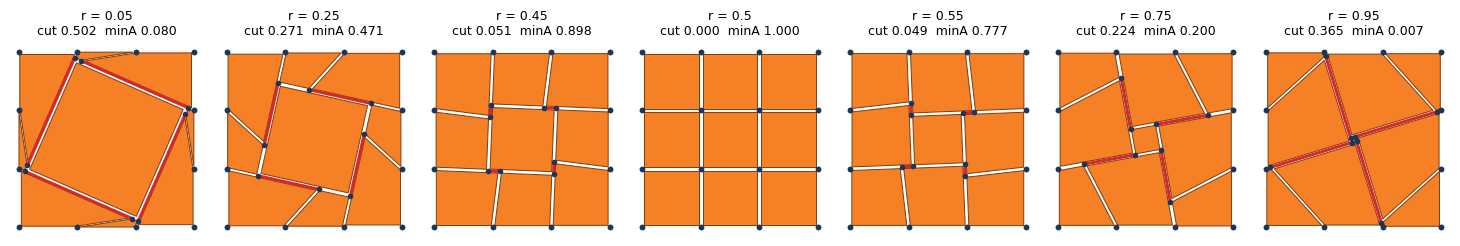

In [2]:
rs = [0.05, 0.25, 0.45, 0.50, 0.55, 0.75, 0.95]
fig, axes = plt.subplots(1, len(rs), figsize=(2.1 * len(rs), 2.6))
for ax, r in zip(axes, rs):
    _, _, coords, panels = build(3, 3, r)
    m = metrics(coords, panels)
    draw(ax, coords, panels, title=f"r = {r}\ncut {m['cut_mean']:.3f}  minA {m['min_area']:.3f}")
fig.tight_layout()

Three things to take away:

1. **`r = 0.5` is the uncut sheet.** Cut length is exactly 0 — the two endpoints of every cut
   coincide, panels tile the square, there is no mechanism. It is a *degenerate* member of the
   family, not a design.
2. **`r < 0.5` and `r > 0.5` are different families**, not mirror images. Compare the panel-area
   spread at 0.05 and 0.95.
3. **Both extremes make slivers.** At `r = 0.95` the smallest panel is ~0.007 of nominal —
   geometrically valid, physically un-cuttable.

Now drag it yourself:

In [3]:
def show_r(r=0.25, M=3, N=3):
    _, _, coords, panels = build(M, N, r)
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    draw(ax, coords, panels, title=f"r = {r:.3f}   z = {np.log(r/(1-r)):+.2f}\n{label(metrics(coords, panels))}")
    plt.show()

interact(show_r,
         r=FloatSlider(0.25, min=0.02, max=0.98, step=0.005, continuous_update=False) if HAVE_WIDGETS else 0.25,
         M=IntSlider(3, min=2, max=6) if HAVE_WIDGETS else 3,
         N=IntSlider(3, min=2, max=6) if HAVE_WIDGETS else 3);

interactive(children=(FloatSlider(value=0.25, continuous_update=False, description='r', max=0.98, min=0.02, st…

## 2. Why a sigmoid at all?

The question is *not* "can JAX differentiate a number in (0,1)" — it can. The question is what
keeps the **optimizer** inside (0,1). Adam takes an unbounded step; nothing stops a raw `r` from
landing at 1.3. The three standard fixes:

| approach | what breaks |
|---|---|
| raw `r`, clip to `[eps, 1-eps]` | clip has zero gradient at the bound, so a design pressed against it becomes a **dead variable**; and `eps` is arbitrary — the true constraint is *open*, which a clip cannot express |
| raw `r` + barrier/penalty | new weight to tune, and a mid-step excursion still hits a singular LES -> `NaN` |
| **reparameterize** `r = sigmoid(z)` | nothing — the bound becomes structurally unreachable, at zero cost |

The `NaN` case is worse than it looks here: every cut vertex comes out of **one shared dense
solve**, so a single bad `r` poisons the whole `(P, 2)` coordinate array, and the NaN-safe guard in
`trainer.py` then zeroes the *entire* design gradient for that step — `bnd_logits` included. The
failure is global, not local. That is the real argument for the reparameterization.

Run the cell to see the sigmoid's own cost — the change of variable is not free:

dr/dz at r=0.5 : 0.2500
dr/dz at r=0.9 : 0.0900   (2.8x weaker)
dr/dz at r=0.98: 0.0196   (12.8x weaker)


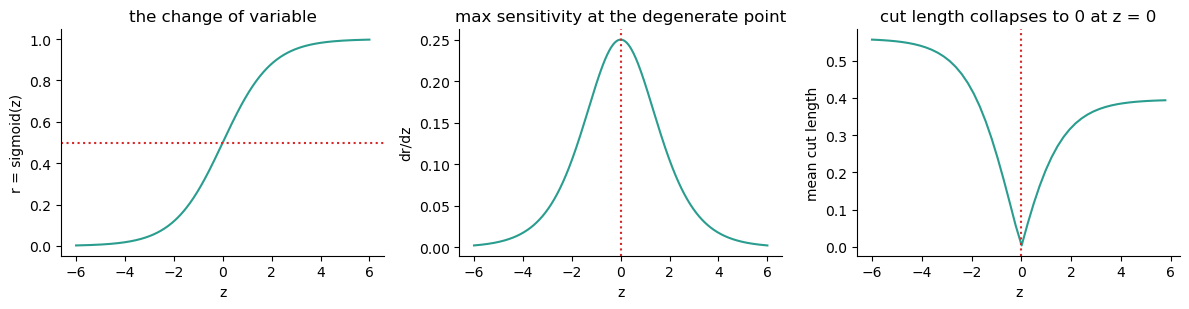

In [4]:
z = np.linspace(-6, 6, 400)
r = 1 / (1 + np.exp(-z))
cut = np.array([metrics(*build(3, 3, ri)[2:])['cut_mean'] for ri in r[::8]])

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(z, r, c="#2A9D8F"); ax[0].axhline(0.5, ls=":", c="#D62828")
ax[0].set(xlabel="z", ylabel="r = sigmoid(z)", title="the change of variable")
ax[1].plot(z, r * (1 - r), c="#2A9D8F"); ax[1].axvline(0, ls=":", c="#D62828")
ax[1].set(xlabel="z", ylabel="dr/dz", title="max sensitivity at the degenerate point")
ax[2].plot(z[::8], cut, c="#2A9D8F"); ax[2].axvline(0, ls=":", c="#D62828")
ax[2].set(xlabel="z", ylabel="mean cut length", title="cut length collapses to 0 at z = 0")
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

print(f"dr/dz at r=0.5 : {0.25:.4f}")
print(f"dr/dz at r=0.9 : {0.9*0.1:.4f}   ({0.25/(0.9*0.1):.1f}x weaker)")
print(f"dr/dz at r=0.98: {0.98*0.02:.4f}   ({0.25/(0.98*0.02):.1f}x weaker)")

So the sigmoid buys an unconstrained optimizer, and pays with:

- its **origin sitting on the uncut sheet** (`z = 0` -> `r = 0.5` -> zero cut length), at the point
  of *maximum* sensitivity — and `regularization: 1.0e-4` in every closed config applies L2 to `z`,
  i.e. shrinkage toward exactly that configuration;
- **saturation** at both ends, so the large-void designs get the weakest gradient;
- a range that guarantees only *mathematical* validity (see §5), not manufacturability.

Note the default `r_init = 0.45` in `data/configs/closed/*.yaml` puts training's starting point
**0.05 from the degenerate ridge**, at a cut length of ~0.05 on a panel pitch of 1.0.

## 3. Per-cut `r` — what spatial variation buys you

`z` is `(rows, cols)`, one value per cut, so `r` can vary across the sheet. This is what lets a
flat sheet deploy into a *non-uniform* target (a dome, a taper) instead of a uniform expansion.

In [5]:
def r_field(kind, rows, cols, lo=0.10, hi=0.45, seed=0):
    if kind == "uniform":
        return np.full((rows, cols), 0.5 * (lo + hi))
    if kind == "gradient-x":
        return np.linspace(lo, hi, rows)[:, None].repeat(cols, 1)
    if kind == "gradient-y":
        return np.linspace(lo, hi, cols)[None, :].repeat(rows, 0)
    if kind == "radial":
        i, j = np.mgrid[0:rows, 0:cols]
        d = np.hypot(i - (rows - 1) / 2, j - (cols - 1) / 2)
        return lo + (hi - lo) * (d / max(d.max(), 1e-9))
    if kind == "random":
        return np.random.default_rng(seed).uniform(lo, hi, (rows, cols))
    raise ValueError(kind)


def show_field(kind="radial", lo=0.10, hi=0.45, M=4, N=4, seed=0):
    struct = build_deploy_structure(M, N)
    r = r_field(kind, struct['rows'], struct['cols'], lo, hi, seed)
    _, _, coords, panels = build(M, N, r)
    fig, ax = plt.subplots(1, 2, figsize=(8.4, 4.0))
    im = ax[0].imshow(r.T, origin="lower", cmap="viridis", vmin=0.02, vmax=0.98)
    ax[0].set(title=f"r field ({kind})", xlabel="cut i", ylabel="cut j")
    fig.colorbar(im, ax=ax[0], fraction=0.046)
    draw(ax[1], coords, panels, title=label(metrics(coords, panels)))
    plt.show()

interact(show_field,
         kind=Dropdown(options=["uniform", "gradient-x", "gradient-y", "radial", "random"],
                       value="radial") if HAVE_WIDGETS else "radial",
         lo=FloatSlider(0.10, min=0.02, max=0.48, step=0.01, continuous_update=False) if HAVE_WIDGETS else 0.10,
         hi=FloatSlider(0.45, min=0.02, max=0.48, step=0.01, continuous_update=False) if HAVE_WIDGETS else 0.45,
         M=IntSlider(4, min=2, max=6) if HAVE_WIDGETS else 4,
         N=IntSlider(4, min=2, max=6) if HAVE_WIDGETS else 4,
         seed=IntSlider(0, min=0, max=20) if HAVE_WIDGETS else 0);

interactive(children=(Dropdown(description='kind', index=3, options=('uniform', 'gradient-x', 'gradient-y', 'r…

Keep `lo` and `hi` on the **same side of 0.5**. Straddling the ridge mixes the two families and
puts near-zero cuts in between — try `lo=0.35, hi=0.48` versus `lo=0.35, hi=0.60` to feel it.

## 4. `bnd_logits` — the boundary sliders

The second design variable. Each of the 4 sheet edges owns `k+1` logits for its `k` sliders; a
softmax turns them into positive gaps and the cumulative sum gives strictly increasing positions.
Strictly increasing means the sliders **cannot cross**, so the outline stays convex — which is the
constraint that actually binds here, and why this one is a softmax rather than a sigmoid.

`skew` below tilts one edge's logits linearly: positive bunches its sliders toward one end.

In [6]:
def skewed_logits(sliders, skews):
    out, off = np.zeros(sliders['n_logits']), 0
    for sk, sz in zip(skews, sliders['logit_sizes']):
        out[off:off + sz] = sk * np.linspace(-1, 1, sz)
        off += sz
    return out


def show_boundary(skew_bottom=0.0, skew_top=0.0, skew_left=0.0, skew_right=0.0, r=0.25, M=4, N=4):
    struct = build_deploy_structure(M, N)
    sliders = build_boundary_edges(struct, spacing=1.0, spacing_y=1.0)
    lg = skewed_logits(sliders, [skew_bottom, skew_top, skew_left, skew_right])
    _, _, coords, panels = build(M, N, r, lg)
    fig, ax = plt.subplots(figsize=(4.4, 4.4))
    draw(ax, coords, panels, title=label(metrics(coords, panels)))
    plt.show()

_s = FloatSlider if HAVE_WIDGETS else (lambda v, **k: v)
interact(show_boundary,
         skew_bottom=_s(0.0, min=-3, max=3, step=0.1, continuous_update=False),
         skew_top=_s(0.0, min=-3, max=3, step=0.1, continuous_update=False),
         skew_left=_s(0.0, min=-3, max=3, step=0.1, continuous_update=False),
         skew_right=_s(0.0, min=-3, max=3, step=0.1, continuous_update=False),
         r=_s(0.25, min=0.02, max=0.48, step=0.01, continuous_update=False),
         M=IntSlider(4, min=2, max=6) if HAVE_WIDGETS else 4,
         N=IntSlider(4, min=2, max=6) if HAVE_WIDGETS else 4);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='skew_bottom', max=3.0, min=…

The outline stays a rectangle no matter how hard you push — sliders only move *tangentially* along
their own edge. That is the whole point of the softmax parameterization.

## 5. Mathematical validity vs physical validity

`r in (0,1)` is exactly Tutte's condition, so *every* picture above is non-self-intersecting.
But look at what the extremes cost in panel area — validity does not imply manufacturability.

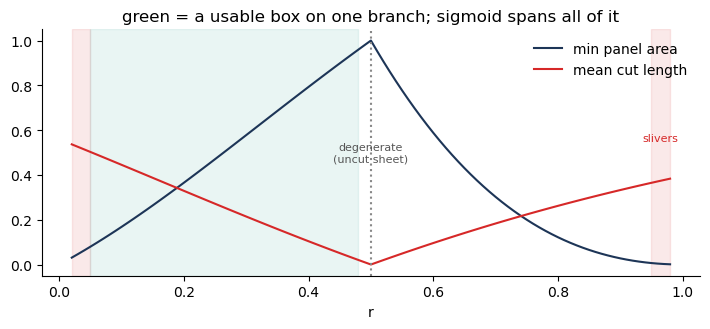

In [7]:
rr = np.linspace(0.02, 0.98, 97)
M_ = np.array([metrics(*build(3, 3, ri)[2:])['min_area'] for ri in rr])
C_ = np.array([metrics(*build(3, 3, ri)[2:])['cut_mean'] for ri in rr])

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(rr, M_, c="#1d3557", label="min panel area")
ax.plot(rr, C_, c="#D62828", label="mean cut length")
ax.axvline(0.5, ls=":", c="#888")
ax.axvspan(0.02, 0.05, color="#D62828", alpha=.10)
ax.axvspan(0.95, 0.98, color="#D62828", alpha=.10)
ax.axvspan(0.05, 0.48, color="#2A9D8F", alpha=.10)
ax.annotate("degenerate\n(uncut sheet)", (0.5, 0.46), ha="center", fontsize=8, color="#555")
ax.annotate("slivers", (0.965, 0.55), ha="center", fontsize=8, color="#D62828")
ax.set(xlabel="r", title="green = a usable box on one branch; sigmoid spans all of it")
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

The shaded green band is roughly what a real sheet can be cut from. A scaled sigmoid puts the
parameterization *there* instead of over all of (0,1):

```python
r = r_lo + (r_hi - r_lo) * jax.nn.sigmoid(z / tau)     # e.g. [0.05, 0.48], tau ~ (r_hi - r_lo) / 4
```

It keeps everything the plain sigmoid buys (unconstrained, smooth, open range, no clipping) while
making the uncut sheet unreachable, committing to one branch, and flattening the gradient variation
across the range actually used. The repo already does exactly this for the ligament width
(`hinge_surrogate.py:65`: `w_lig = 1 + 9*sigmoid(logit)`) — `z` is the last design variable still
on the raw (0,1).

Compare the two reachable sets directly:

plain sigmoid, dr/dz spread over [0.05, 0.48]: 5.2x
scaled sigmoid over the same band          : ~1.4x by construction


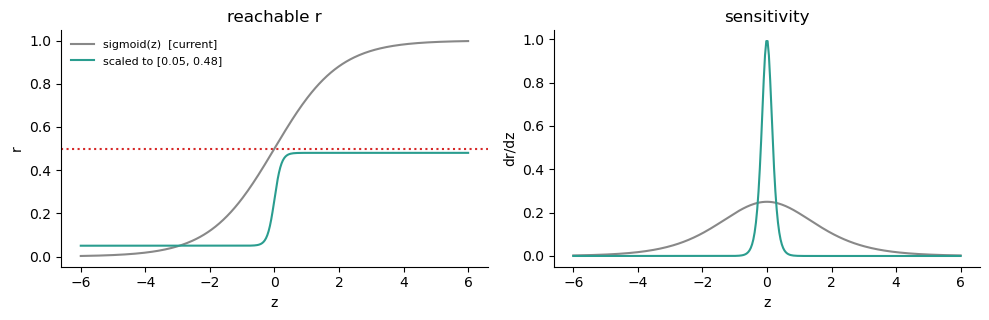

In [8]:
zz = np.linspace(-6, 6, 300)
plain = 1 / (1 + np.exp(-zz))
lo, hi = 0.05, 0.48
tau = (hi - lo) / 4
scaled = lo + (hi - lo) / (1 + np.exp(-zz / tau))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(zz, plain, c="#888", label="sigmoid(z)  [current]")
ax[0].plot(zz, scaled, c="#2A9D8F", label=f"scaled to [{lo}, {hi}]")
ax[0].axhline(0.5, ls=":", c="#D62828")
ax[0].set(xlabel="z", ylabel="r", title="reachable r"); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(zz, plain * (1 - plain), c="#888")
ax[1].plot(zz, (scaled - lo) * (hi - scaled) / (hi - lo) / tau, c="#2A9D8F")
ax[1].set(xlabel="z", ylabel="dr/dz", title="sensitivity")
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

band = (rr >= lo) & (rr <= hi)
g = rr * (1 - rr)
print(f"plain sigmoid, dr/dz spread over [{lo}, {hi}]: {g[band].max()/g[band].min():.1f}x")
print(f"scaled sigmoid over the same band          : ~1.4x by construction")

---

**Caveat.** Everything above is a property of the *parameterization*, shown geometrically. It is
not a convergence experiment — whether the scaled version actually trains better is untested.